#### Prediction-3 neighbor effects by occupation sequence-ability
#### By: Peyman Shahidi (heterogeneity build)
#### Created: 2026-07-25

**Question.** The model's local-context mechanism should matter most where workflows are genuinely sequential.
This notebook interacts the Prediction-3 neighbor flags with the occupation-level **sequence-ability index**
(stage-position Kendall tau from `onet_gwaStage_sequenceability.ipynb`).

**Two designs, paper baseline controls throughout (focal `is_exposed`, `num_tasks`):**
1. **Median split.** Occupations are split at the median tau (computed across occupations in the full-eligible
   analytic sample; the same threshold is applied to the GPT-filtered sample). The six specifications are
   re-estimated within each half; the comparison figure adds the paper's all-occupation estimate as reference.
2. **Continuous interaction.** `seq_z` (tau standardized across full-eligible-sample occupations) enters with
   its main effect and interactions with all four neighbor flags. Because logit interaction coefficients do not
   equal marginal-effect differences, we report the neighbor AME evaluated at `seq_z = +1` and `seq_z = -1`
   and the delta-method DWA-clustered test of the difference, alongside the clustered p-value of the raw
   interaction coefficient.

**Caveat.** The index is estimated with noise, especially for short workflows, which attenuates heterogeneity
toward zero; the split design is the more robust read.

**Outputs.** `data/computed_objects/execTypeVaryingDWA_anthropicIndex_sequenceability/` and
`writeup/plots/execTypeVaryingDWA_sequenceability/`.

In [1]:
import os, glob
import numpy as np, pandas as pd
import patsy
import statsmodels.formula.api as smf
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 220)

In [2]:
dependent_var = 'is_ai'
TARGET_REGS = ['prev2_is_ai', 'prev_is_ai', 'next_is_ai', 'next2_is_ai']
VAR_LABELS = {'prev2_is_ai': '(t-2) Task AI', 'prev_is_ai': '(t-1) Task AI',
              'next_is_ai': '(t+1) Task AI', 'next2_is_ai': '(t+2) Task AI'}
SPEC_ORDER = ['no_fe_no_dwa', 'major_fe_no_dwa', 'minor_fe_no_dwa', 'no_fe_with_dwa',
              'no_fe_no_dwa_withTaskDWACount', 'no_fe_with_dwa_withTaskDWACount']
star = lambda p: "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

In [3]:
main_folder_path = ".."
input_data_path = f"{main_folder_path}/data"
merged_file = f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"
seqability_file = f"{input_data_path}/computed_objects/gwaStage_sequenceability/occupation_sequenceability.csv"
reference_results_file = f"{input_data_path}/computed_objects/execTypeVaryingDWA_anthropicIndex_E1E2exposureControls/ame_results_allVariants.csv"

output_data_path = f"{input_data_path}/computed_objects/execTypeVaryingDWA_anthropicIndex_sequenceability"
output_plot_path = f"{main_folder_path}/writeup/plots/execTypeVaryingDWA_sequenceability"
for p in [output_data_path, output_plot_path]: os.makedirs(p, exist_ok=True)

## DWA helpers and analytic samples (baseline construction), with the sequence-ability index merged in

In [4]:
dwa_csv_files = glob.glob(os.path.join(f"{input_data_path}/computed_objects/similar_dwa_tasks/similarTasks", "*.csv"))
dwa_dfs = [pd.read_csv(f) for f in dwa_csv_files]
df_all = pd.concat([d for d in dwa_dfs if len(d) > 1], ignore_index=True)
repetitive_dwa_task_ids = df_all['Task ID'].unique().tolist()

dwa_task_mapping = pd.read_csv(f"{input_data_path}/computed_objects/similar_dwa_tasks/dwa_task_mapping.csv")
dwa_task_counts = dwa_task_mapping.groupby('Task ID')['DWA ID'].nunique().reset_index(name='n')
unique_task_dwa_mapping = dwa_task_counts[dwa_task_counts['n'] == 1]['Task ID'].tolist()

_md = pd.read_csv(merged_file); _md['is_manual'] = _md['label'] == 'Manual'
_md = _md.merge(dwa_task_mapping, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
_dg = _md.groupby(['DWA ID', 'DWA Title']).agg(no=('O*NET-SOC Code', 'nunique'), fm=('is_manual', 'mean')).reset_index()
dwas_varying_exec_types_ids = _dg[(_dg['no'] > 1) & (_dg['fm'] > 0) & (_dg['fm'] < 1)]['DWA ID'].unique().tolist()

def build_dataset():
    """Baseline Prediction-3 samples (identical to the main pipeline). Returns (full_eligible, gpt_filtered)."""
    d = pd.read_csv(merged_file)
    d = d[['O*NET-SOC Code', 'Occupation Title', 'Task ID', 'Task Title', 'Task Position',
           'Major_Group_Code', 'Minor_Group_Code', 'human_labels', 'label']].copy()
    d['is_ai'] = d['label'].isin(['Augmentation', 'Automation']).astype(int)
    d['is_exposed'] = d['human_labels'].isin(['E1']).astype(int)
    n = d.groupby('O*NET-SOC Code')['Task ID'].nunique().reset_index().rename(columns={'Task ID': 'num_tasks'})
    d = d.merge(n, on='O*NET-SOC Code', how='left')
    d['Task Position'] = pd.to_numeric(d['Task Position'], errors='coerce')
    d = d.sort_values(['O*NET-SOC Code', 'Task Position']).reset_index(drop=True)
    g = d.groupby('O*NET-SOC Code')['is_ai']
    d['prev_is_ai'] = g.shift(1); d['prev2_is_ai'] = g.shift(2)
    d['next_is_ai'] = g.shift(-1); d['next2_is_ai'] = g.shift(-2)
    nb_ai = ['prev_is_ai', 'prev2_is_ai', 'next_is_ai', 'next2_is_ai']
    d = d.dropna(subset=nb_ai).reset_index(drop=True)
    for c in nb_ai: d[c] = d[c].astype(int)
    d = d.merge(dwa_task_mapping, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
    d = d[d['Task ID'].isin(unique_task_dwa_mapping)].reset_index(drop=True)
    d = d.drop_duplicates(subset=['O*NET-SOC Code', 'Task ID']).reset_index(drop=True)
    d = d[~d['DWA ID'].isna()].reset_index(drop=True)
    occ = d.groupby('DWA ID')['O*NET-SOC Code'].nunique(); keep = occ[occ > 1].index
    d = d[d['DWA ID'].isin(keep)].reset_index(drop=True)
    cnt = d.groupby(['DWA ID', 'O*NET-SOC Code'])['Task ID'].nunique().reset_index(name='num_tasks_in_dwa_within_occupation')
    d = d.merge(cnt, on=['DWA ID', 'O*NET-SOC Code'], how='left')
    filt = d[(d['DWA ID'].isin(dwas_varying_exec_types_ids) & d['Task ID'].isin(repetitive_dwa_task_ids))].reset_index(drop=True)
    for x in (d, filt):
        sc = x.select_dtypes(include=['string']).columns; x[sc] = x[sc].astype(object)
    return d, filt

seq = pd.read_csv(seqability_file)[['O*NET-SOC Code', 'tau', 'n_staged']].rename(columns={'tau': 'seq_tau'})
ds_full, ds_filt = build_dataset()
ds_full = ds_full.merge(seq, on='O*NET-SOC Code', how='left')
ds_filt = ds_filt.merge(seq, on='O*NET-SOC Code', how='left')
miss_full = ds_full['seq_tau'].isna().sum(); miss_filt = ds_filt['seq_tau'].isna().sum()
ds_full = ds_full.dropna(subset=['seq_tau']).reset_index(drop=True)
ds_filt = ds_filt.dropna(subset=['seq_tau']).reset_index(drop=True)

# split threshold and standardization: occupation-level, computed on the full-eligible sample
occ_tau = ds_full.drop_duplicates('O*NET-SOC Code')['seq_tau']
TAU_MEDIAN, TAU_MEAN, TAU_SD = float(occ_tau.median()), float(occ_tau.mean()), float(occ_tau.std(ddof=1))
for x in (ds_full, ds_filt):
    x['high_seq'] = (x['seq_tau'] >= TAU_MEDIAN).astype(int)
    x['seq_z'] = (x['seq_tau'] - TAU_MEAN) / TAU_SD

print(f"dropped rows without index: full {miss_full}, gpt {miss_filt}")
print(f"occupation-level tau: median {TAU_MEDIAN:.3f} | mean {TAU_MEAN:.3f} | sd {TAU_SD:.3f}")
for nm, x in [('full-eligible', ds_full), ('gpt-filtered', ds_filt)]:
    o = x.drop_duplicates('O*NET-SOC Code')
    print(f"{nm}: {len(x):,} rows, {len(o):,} occupations | high half: {int(o['high_seq'].sum()):,} occs "
          f"({int(x['high_seq'].sum()):,} rows) | low half: {int((1-o['high_seq']).sum()):,} occs "
          f"({int((1-x['high_seq']).sum()):,} rows)")

dropped rows without index: full 47, gpt 2
occupation-level tau: median 0.160 | mean 0.160 | sd 0.221
full-eligible: 10,661 rows, 864 occupations | high half: 432 occs (5,183 rows) | low half: 432 occs (5,478 rows)
gpt-filtered: 3,687 rows, 740 occupations | high half: 368 occs (1,804 rows) | low half: 372 occs (1,883 rows)


## Estimation machinery

In [5]:
def _spec_list(df, base, dep=dependent_var):
    df = df.copy(); df['DWA_ID'] = df['DWA ID']
    df_dwa = df.groupby('DWA_ID').filter(lambda g: g[dep].nunique() > 1)
    return [
        ('no_fe_no_dwa',                    base,                                                       df,     'DWA ID', 'None',  False, False),
        ('major_fe_no_dwa',                 base + ' + C(Major_Group_Code)',
            df.groupby('Major_Group_Code').filter(lambda g: g[dep].nunique() > 1),                      'DWA ID', 'Major', False, False),
        ('minor_fe_no_dwa',                 base + ' + C(Minor_Group_Code)',
            df.groupby('Minor_Group_Code').filter(lambda g: g[dep].nunique() > 1),                      'DWA ID', 'Minor', False, False),
        ('no_fe_with_dwa',                  base + ' + C(DWA_ID)',                                      df_dwa, 'DWA_ID', 'None',  True,  False),
        ('no_fe_no_dwa_withTaskDWACount',   base + ' + num_tasks_in_dwa_within_occupation',             df_dwa, 'DWA_ID', 'None',  False, True),
        ('no_fe_with_dwa_withTaskDWACount', base + ' + C(DWA_ID) + num_tasks_in_dwa_within_occupation', df_dwa, 'DWA_ID', 'None',  True,  True),
    ]

def _fit(formula, data, cluster):
    try:
        return smf.logit(formula, data=data).fit(disp=False, cov_type='cluster',
                                                 cov_kwds={'groups': data[cluster], 'use_correction': True})
    except Exception:
        return smf.logit(formula, data=data).fit(disp=False, method='bfgs', maxiter=500, cov_type='cluster',
                                                 cov_kwds={'groups': data[cluster], 'use_correction': True})

def _pred_parts(res, df):
    di = res.model.data.design_info
    X = np.asarray(patsy.build_design_matrices([di], df)[0])
    beta = np.asarray(res.params)
    p = 1.0 / (1.0 + np.exp(-(X @ beta)))
    return p, X

def _ame_grad(res, df, v, overrides=None):
    """AME of binary v (with optional column overrides applied first) and its gradient wrt params."""
    d1 = df.copy(); d0 = df.copy()
    if overrides:
        for k, val in overrides.items():
            d1[k] = val; d0[k] = val
    d1[v] = 1; d0[v] = 0
    p1, X1 = _pred_parts(res, d1); p0, X0 = _pred_parts(res, d0)
    ame = float(np.mean(p1 - p0))
    grad = ((p1 * (1 - p1))[:, None] * X1 - (p0 * (1 - p0))[:, None] * X0).mean(axis=0)
    return ame, grad

def _se_p(res, grad):
    V = np.asarray(res.cov_params())
    se = float(np.sqrt(grad @ V @ grad))
    return se, (float(2 * norm.sf(abs(1))) if False else None)

def run_split(df, dataset_name, group_label, dep=dependent_var):
    """Six specs with paper baseline controls on a subsample; delta-method clustered AME SEs."""
    base = f'{dep} ~ ' + ' + '.join(TARGET_REGS) + ' + is_exposed + num_tasks'
    rows = []
    for name, formula, data, cluster, fe_label, dwa_fe, dwacount in _spec_list(df, base):
        try:
            res = _fit(formula, data, cluster)
            V = np.asarray(res.cov_params())
            for v in TARGET_REGS:
                ame, grad = _ame_grad(res, data, v)
                se = float(np.sqrt(grad @ V @ grad))
                p = float(2 * norm.sf(abs(ame / se))) if se > 0 else np.nan
                rows.append({'dataset': dataset_name, 'series': group_label, 'model': name,
                             'nobs': int(res.nobs), 'term': v, 'ame_coef': ame, 'ame_se': se, 'p_value': p})
        except Exception as e:
            print(f"  [{dataset_name}|{group_label}|{name}] failed: {e}")
    return pd.DataFrame(rows)

def run_interaction(df, dataset_name, dep=dependent_var):
    """Continuous design: neighbor flags interacted with seq_z. Reports the neighbor AME at seq_z = -1 and
    +1, the delta-method clustered test of the difference, and the raw interaction coefficient p-value."""
    inter = ' + '.join([f'{v}:seq_z' for v in TARGET_REGS])
    base = (f'{dep} ~ ' + ' + '.join(TARGET_REGS) + ' + seq_z + ' + inter + ' + is_exposed + num_tasks')
    rows = []
    for name, formula, data, cluster, fe_label, dwa_fe, dwacount in _spec_list(df, base):
        try:
            res = _fit(formula, data, cluster)
            V = np.asarray(res.cov_params())
            for v in TARGET_REGS:
                a_hi, g_hi = _ame_grad(res, data, v, overrides={'seq_z': 1.0})
                a_lo, g_lo = _ame_grad(res, data, v, overrides={'seq_z': -1.0})
                gd = g_hi - g_lo
                se_d = float(np.sqrt(gd @ V @ gd))
                p_d = float(2 * norm.sf(abs((a_hi - a_lo) / se_d))) if se_d > 0 else np.nan
                cname = f'{v}:seq_z'
                rows.append({'dataset': dataset_name, 'model': name, 'term': v, 'nobs': int(res.nobs),
                             'ame_at_minus1sd': a_lo, 'ame_at_plus1sd': a_hi,
                             'ame_diff': a_hi - a_lo, 'ame_diff_se': se_d, 'ame_diff_p': p_d,
                             'interaction_coef': float(res.params[cname]),
                             'interaction_coef_p': float(res.pvalues[cname])})
        except Exception as e:
            print(f"  [{dataset_name}|interaction|{name}] failed: {e}")
    return pd.DataFrame(rows)

## Run: median split and continuous interaction

In [6]:
split_rows, inter_rows = [], []
for ds_name, ds in [('full_eligible', ds_full), ('gpt_filtered', ds_filt)]:
    print(f">>> {ds_name}: low half"); split_rows.append(run_split(ds[ds['high_seq'] == 0], ds_name, 'low_seq'))
    print(f">>> {ds_name}: high half"); split_rows.append(run_split(ds[ds['high_seq'] == 1], ds_name, 'high_seq'))
    print(f">>> {ds_name}: interaction"); inter_rows.append(run_interaction(ds, ds_name))
split_res = pd.concat(split_rows, ignore_index=True)
inter_res = pd.concat(inter_rows, ignore_index=True)
split_res.to_csv(f"{output_data_path}/ame_results_seqSplit.csv", index=False)
inter_res.to_csv(f"{output_data_path}/ame_results_seqInteraction.csv", index=False)
print(f"\nSaved {len(split_res):,} split rows and {len(inter_res):,} interaction rows -> {output_data_path}")

>>> full_eligible: low half


>>> full_eligible: high half


>>> full_eligible: interaction


>>> gpt_filtered: low half


>>> gpt_filtered: high half


>>> gpt_filtered: interaction



Saved 96 split rows and 48 interaction rows -> ../data/computed_objects/execTypeVaryingDWA_anthropicIndex_sequenceability


## Split results next to the paper's all-occupation estimates

In [7]:
reference = pd.read_csv(reference_results_file)
ref = reference[reference['variant'] == 'baseline'][['dataset', 'model', 'term', 'nobs', 'ame_coef', 'ame_se', 'p_value']].copy()
ref['series'] = 'all_occs'
plotdf = pd.concat([ref, split_res], ignore_index=True)
SERIES_ORDER = ['all_occs', 'low_seq', 'high_seq']
SERIES_LABEL = {'all_occs': 'All occupations (paper)', 'low_seq': 'Low sequence-ability half',
                'high_seq': 'High sequence-ability half'}

def compact(ds_name):
    print(f"\n=== {ds_name}: immediate neighbors (t-1, t+1) ===")
    print(f"{'spec':<34}{'series':<30}{'(t-1) AI':>12}{'(t+1) AI':>12}{'N':>9}")
    for sp in SPEC_ORDER:
        for s in SERIES_ORDER:
            sub = plotdf[(plotdf.dataset == ds_name) & (plotdf.series == s) & (plotdf.model == sp)]
            if not len(sub): continue
            def cell(t):
                x = sub[sub.term == t]
                return f"{x['ame_coef'].iloc[0]:.3f}{star(x['p_value'].iloc[0])}" if len(x) else '.'
            print(f"{sp:<34}{SERIES_LABEL[s]:<30}{cell('prev_is_ai'):>12}{cell('next_is_ai'):>12}"
                  f"{int(sub['nobs'].iloc[0]):>9,}")

compact('full_eligible')
compact('gpt_filtered')

def wide_table(ds_name):
    rows = []
    for term in TARGET_REGS:
        r = {'neighbor': VAR_LABELS[term]}
        for sp in SPEC_ORDER:
            for s in SERIES_ORDER:
                x = plotdf[(plotdf.dataset == ds_name) & (plotdf.series == s) &
                           (plotdf.model == sp) & (plotdf.term == term)]
                r[f'{sp}|{s}'] = f"{x['ame_coef'].iloc[0]:.3f}{star(x['p_value'].iloc[0])}" if len(x) else '.'
        rows.append(r)
    nrow = {'neighbor': 'N (obs)'}
    for sp in SPEC_ORDER:
        for s in SERIES_ORDER:
            x = plotdf[(plotdf.dataset == ds_name) & (plotdf.series == s) & (plotdf.model == sp)]
            nrow[f'{sp}|{s}'] = f"{int(x['nobs'].iloc[0]):,}" if len(x) else '.'
    rows.append(nrow)
    return pd.DataFrame(rows)

for ds_name, fname in [('full_eligible', 'ame_comparison_full_eligible.csv'),
                       ('gpt_filtered', 'ame_comparison_gpt_filtered.csv')]:
    wide_table(ds_name).to_csv(f"{output_data_path}/{fname}", index=False)
    print(f"Saved {fname}")


=== full_eligible: immediate neighbors (t-1, t+1) ===
spec                              series                            (t-1) AI    (t+1) AI        N
no_fe_no_dwa                      All occupations (paper)           0.124***    0.117***   10,708
no_fe_no_dwa                      Low sequence-ability half         0.114***    0.110***    5,478
no_fe_no_dwa                      High sequence-ability half        0.134***    0.122***    5,183
major_fe_no_dwa                   All occupations (paper)           0.061***    0.057***   10,708
major_fe_no_dwa                   Low sequence-ability half         0.055***    0.054***    5,478
major_fe_no_dwa                   High sequence-ability half        0.062***    0.058***    5,105
minor_fe_no_dwa                   All occupations (paper)           0.051***    0.048***    9,861
minor_fe_no_dwa                   Low sequence-ability half         0.043***    0.042***    4,599
minor_fe_no_dwa                   High sequence-ability half   

## Continuous interaction: neighbor AME at low vs high sequence-ability

In [8]:
for ds_name in ['full_eligible', 'gpt_filtered']:
    print(f"\n=== {ds_name}: AME of neighbor flag at seq_z = -1 vs +1 (interacted model) ===")
    print(f"{'spec':<34}{'term':<16}{'AME @ -1sd':>11}{'AME @ +1sd':>11}{'diff':>10}{'p(diff)':>9}{'p(coef)':>9}")
    for sp in SPEC_ORDER:
        for v in ['prev_is_ai', 'next_is_ai', 'prev2_is_ai', 'next2_is_ai']:
            x = inter_res[(inter_res.dataset == ds_name) & (inter_res.model == sp) & (inter_res.term == v)]
            if not len(x): continue
            r = x.iloc[0]
            print(f"{sp:<34}{VAR_LABELS[v]:<16}{r['ame_at_minus1sd']:>11.3f}{r['ame_at_plus1sd']:>11.3f}"
                  f"{r['ame_diff']:>7.3f}{star(r['ame_diff_p']):<3}{r['ame_diff_p']:>9.3f}{r['interaction_coef_p']:>9.3f}")


=== full_eligible: AME of neighbor flag at seq_z = -1 vs +1 (interacted model) ===
spec                              term             AME @ -1sd AME @ +1sd      diff  p(diff)  p(coef)
no_fe_no_dwa                      (t-1) Task AI         0.123      0.125  0.001       0.964    0.903
no_fe_no_dwa                      (t+1) Task AI         0.116      0.117  0.001       0.972    0.906
no_fe_no_dwa                      (t-2) Task AI         0.053      0.077  0.024       0.343    0.385
no_fe_no_dwa                      (t+2) Task AI         0.051      0.047 -0.004       0.854    0.793
major_fe_no_dwa                   (t-1) Task AI         0.061      0.060 -0.000       0.981    0.918
major_fe_no_dwa                   (t+1) Task AI         0.056      0.059  0.003       0.883    0.939
major_fe_no_dwa                   (t-2) Task AI         0.005      0.023  0.018       0.338    0.340
major_fe_no_dwa                   (t+2) Task AI         0.006      0.002 -0.004       0.824    0.820
minor_f

## Robustness forests (GPT-prompt robustness style): all occupations vs low and high halves

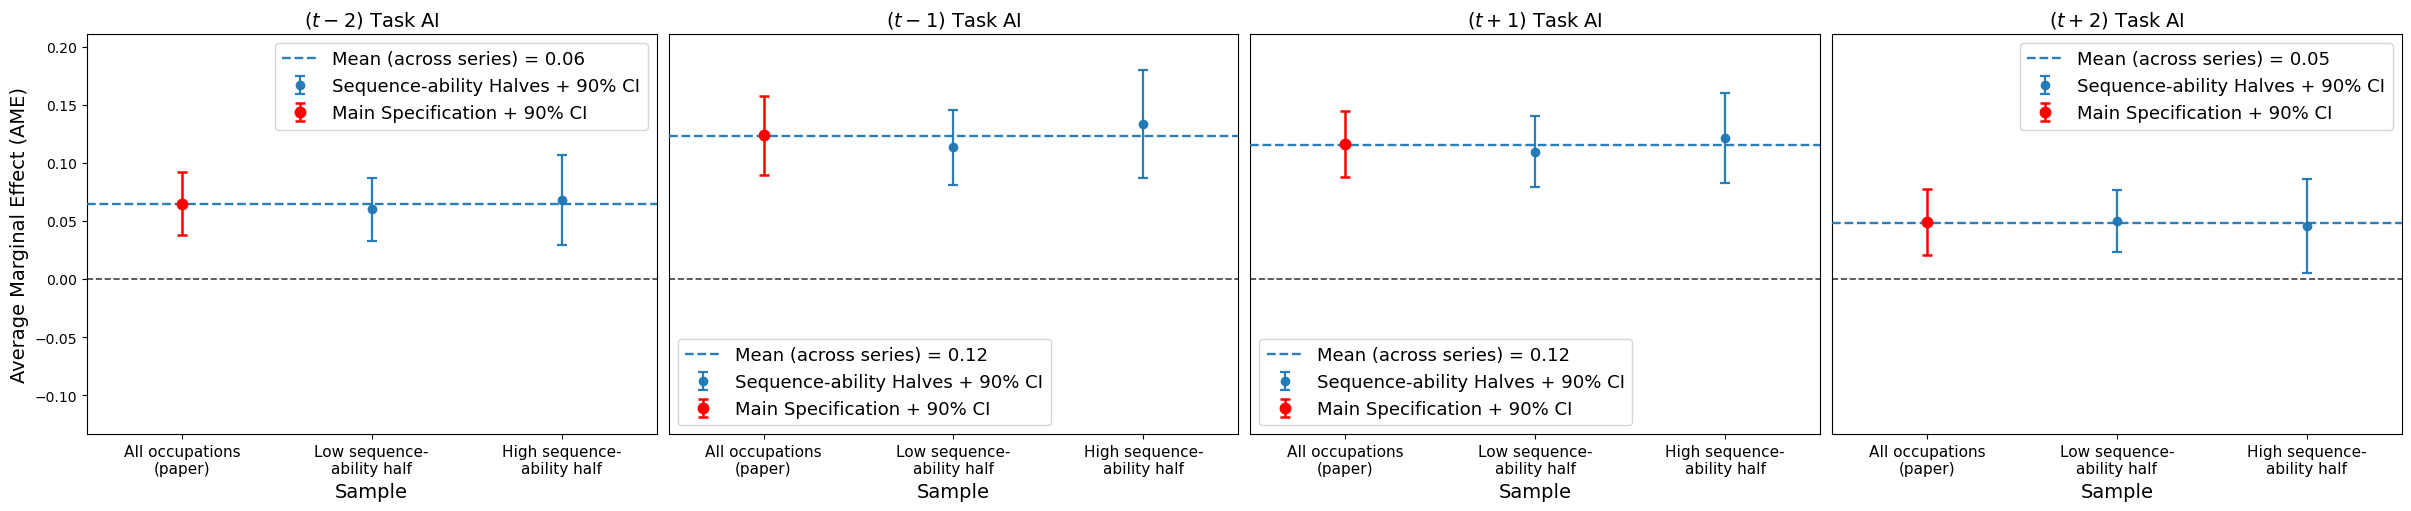

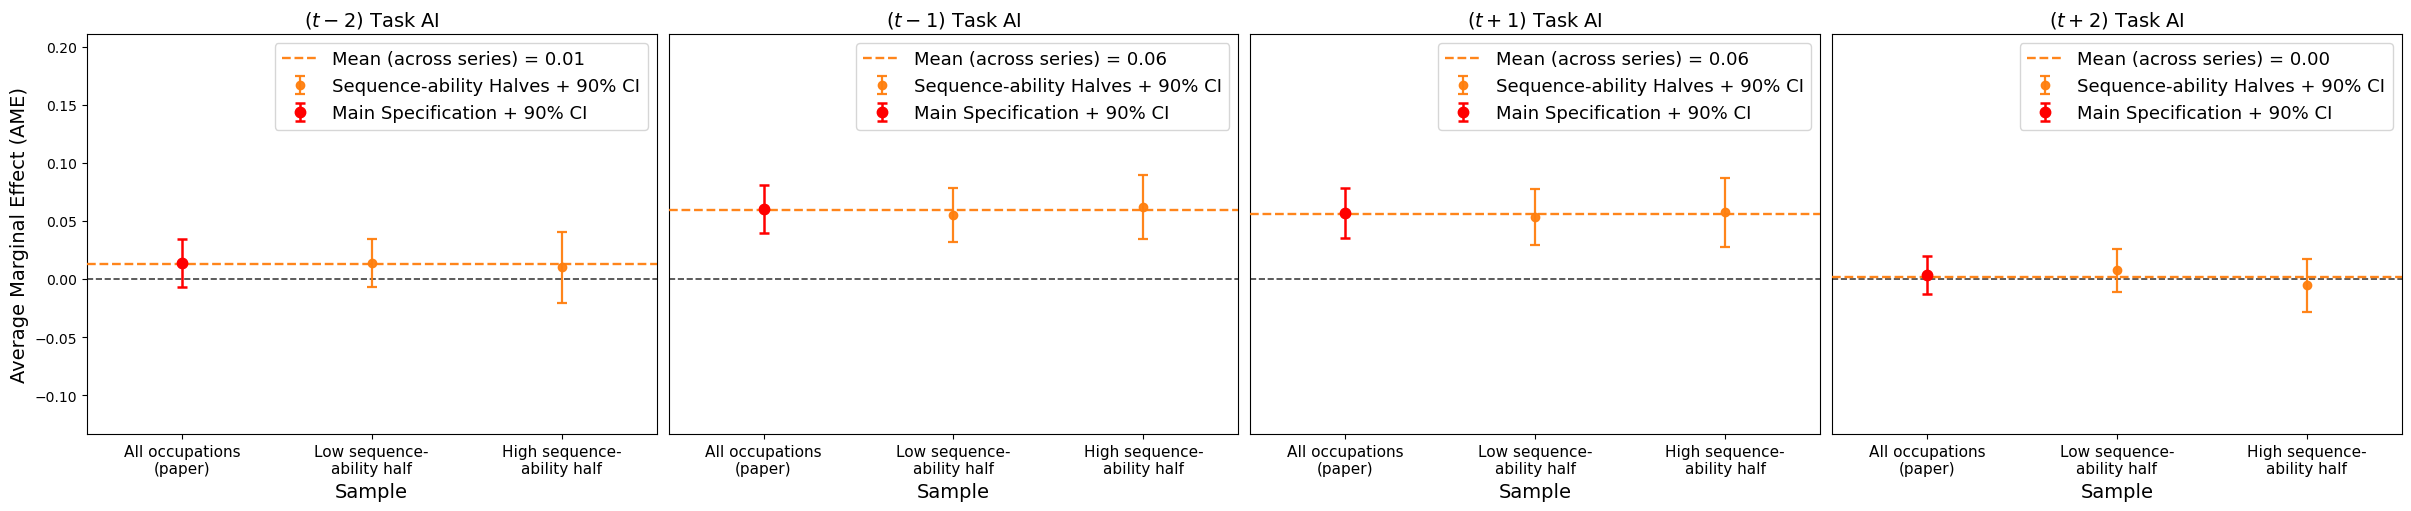

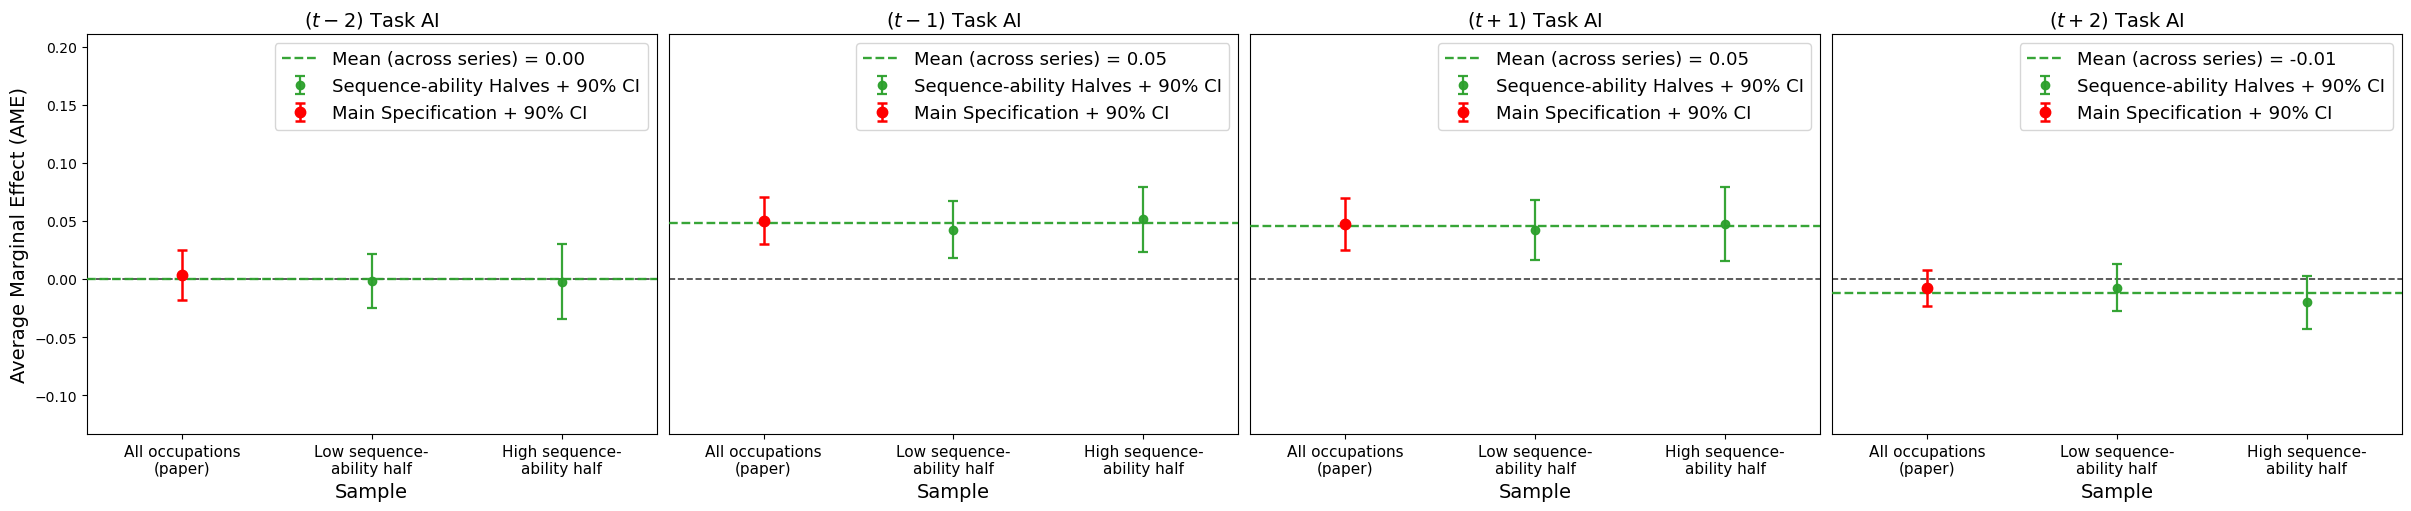

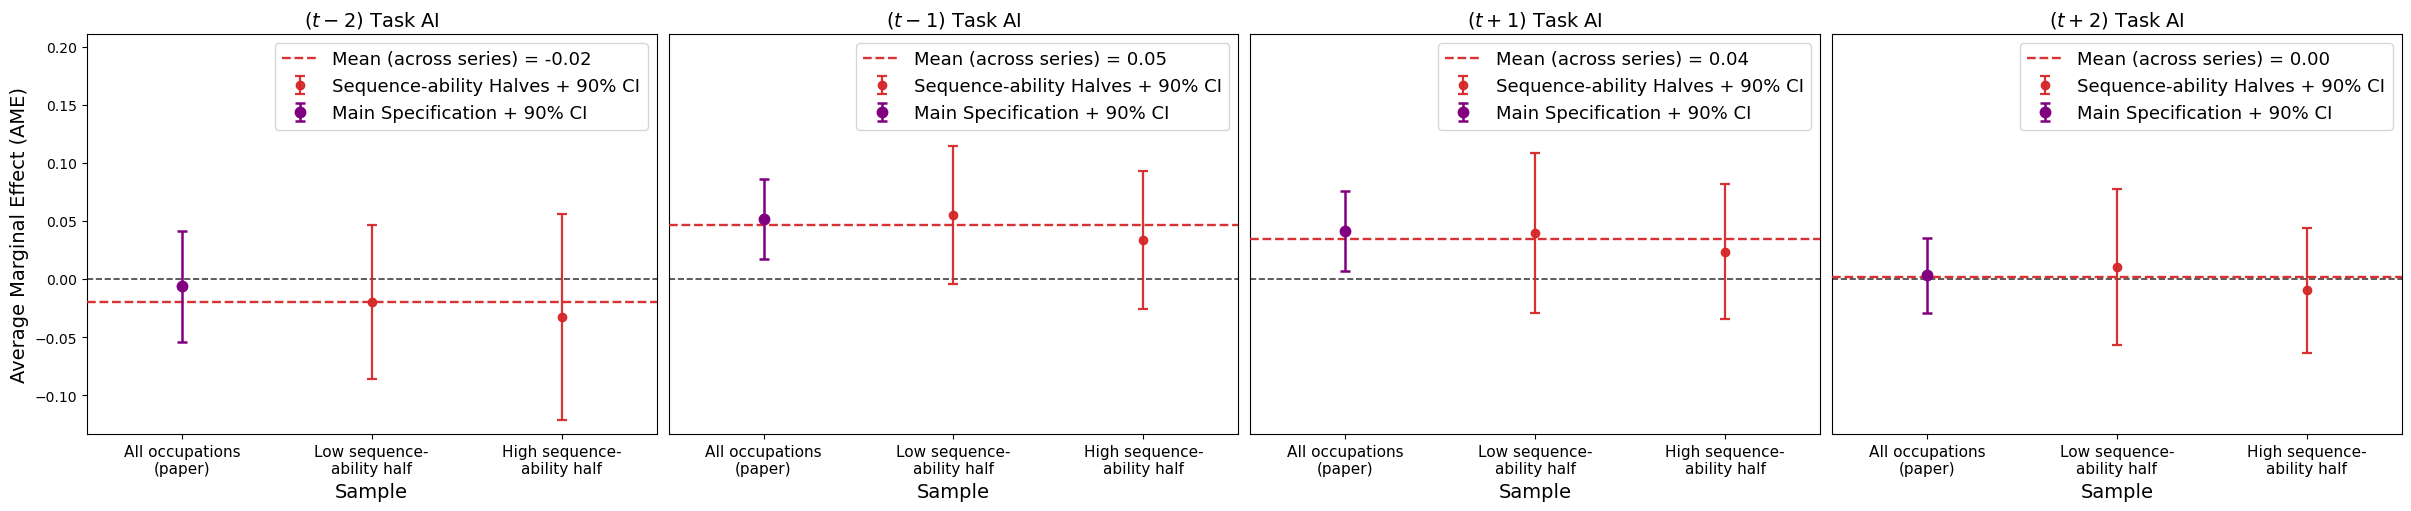

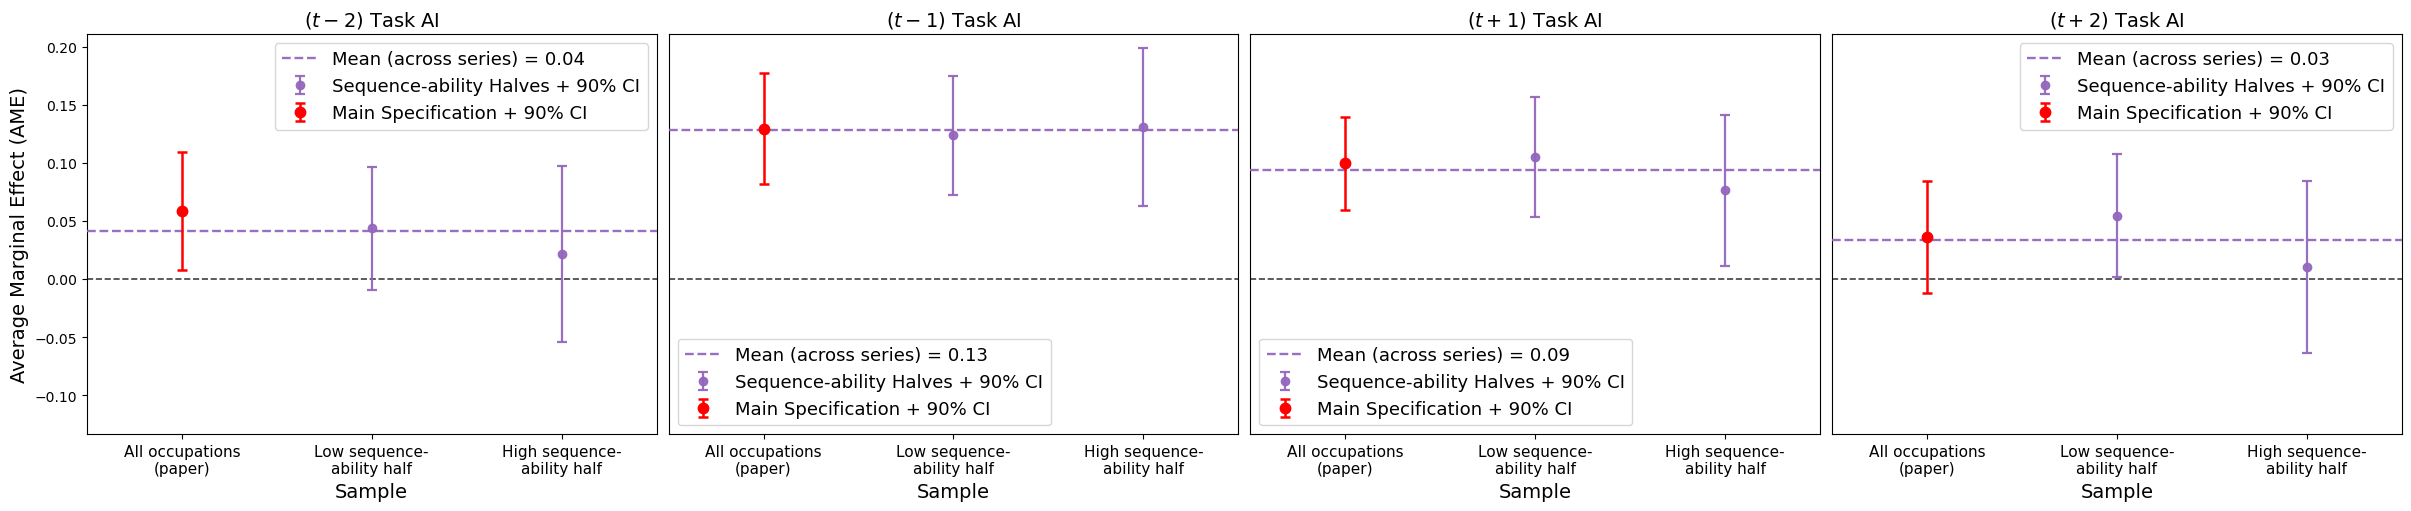

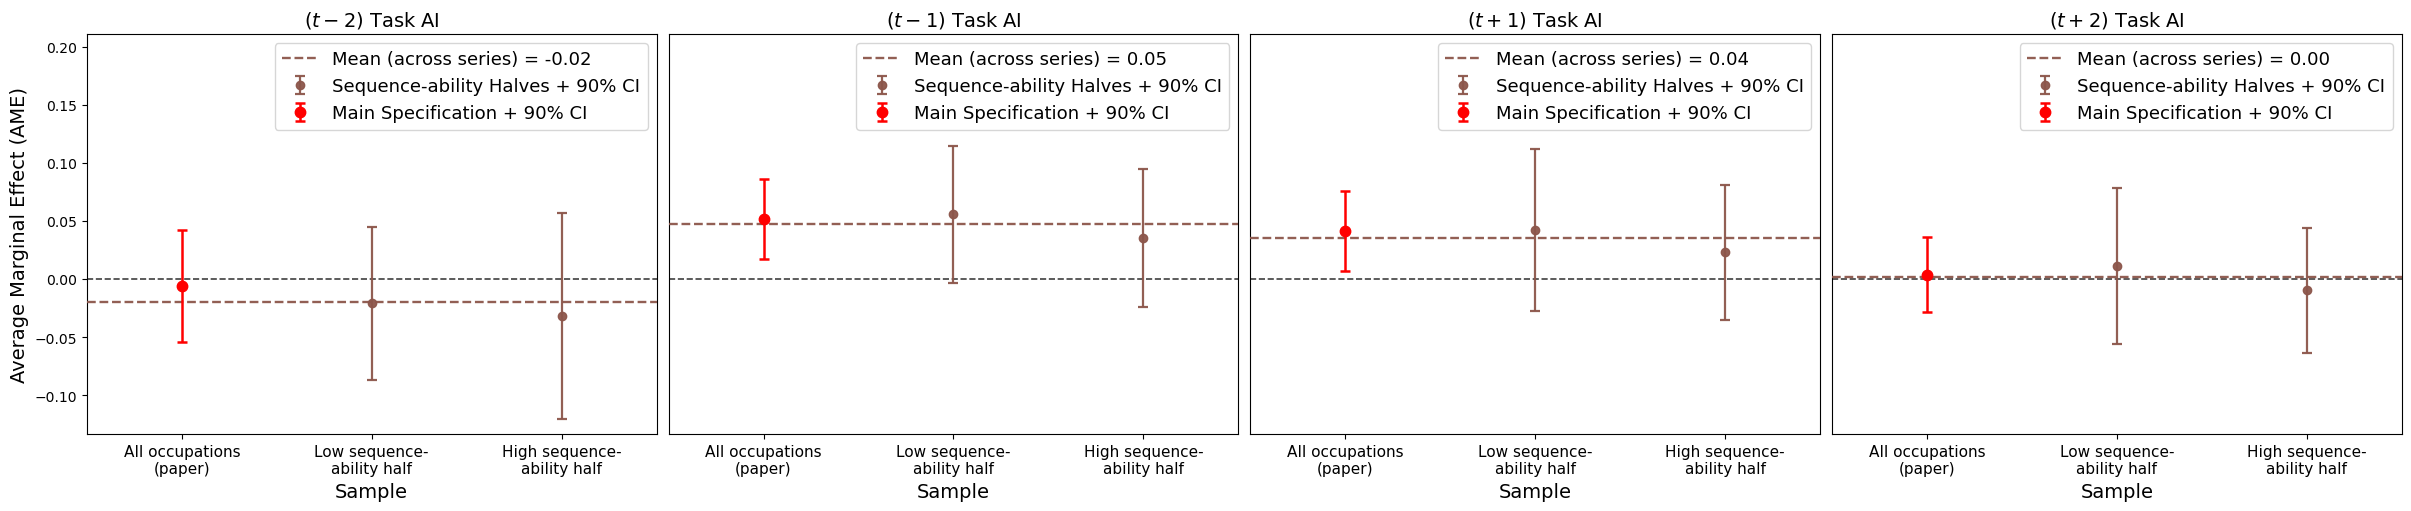

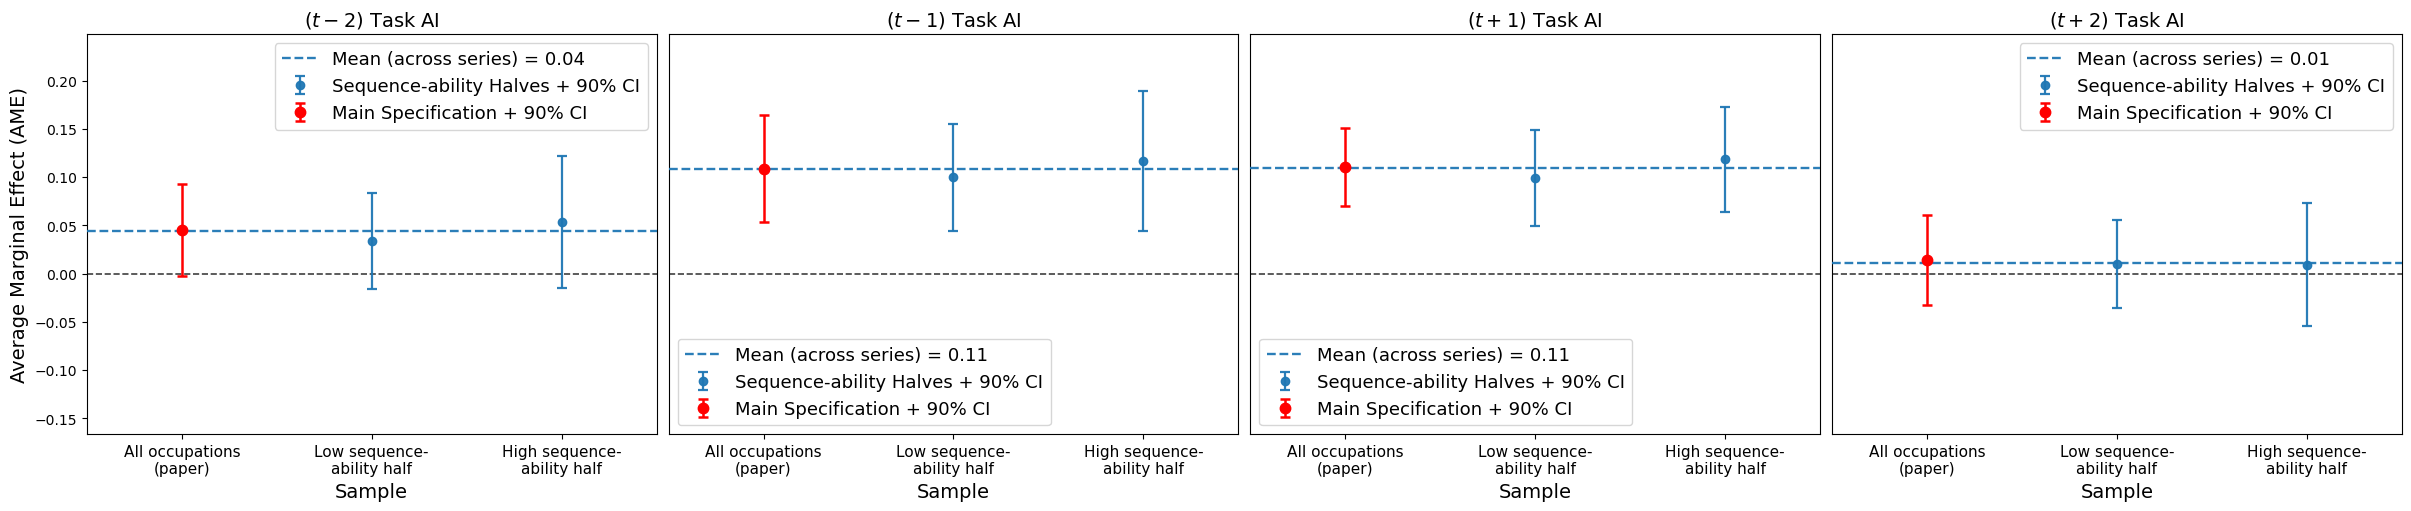

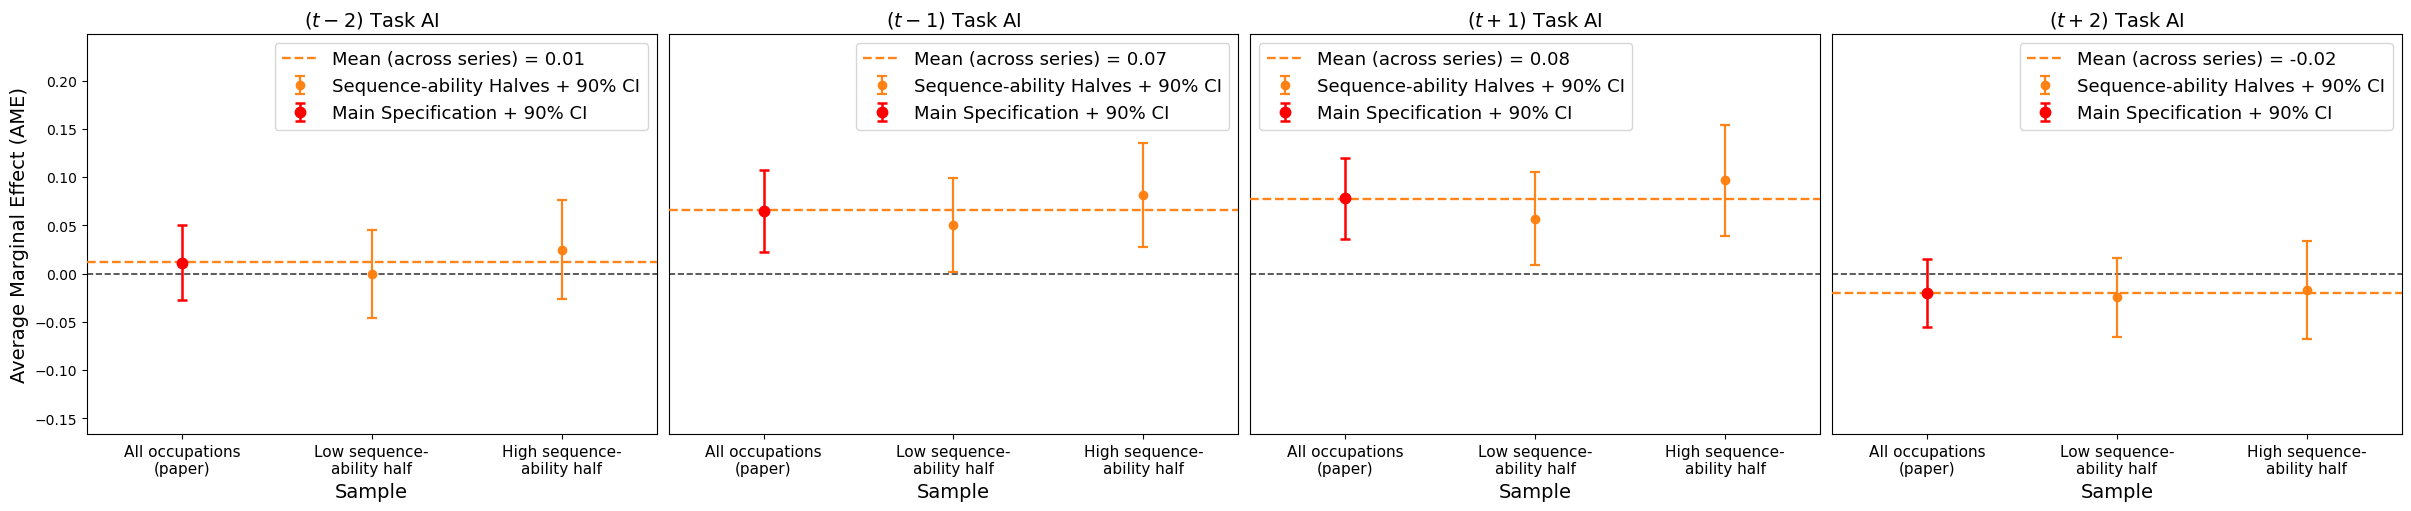

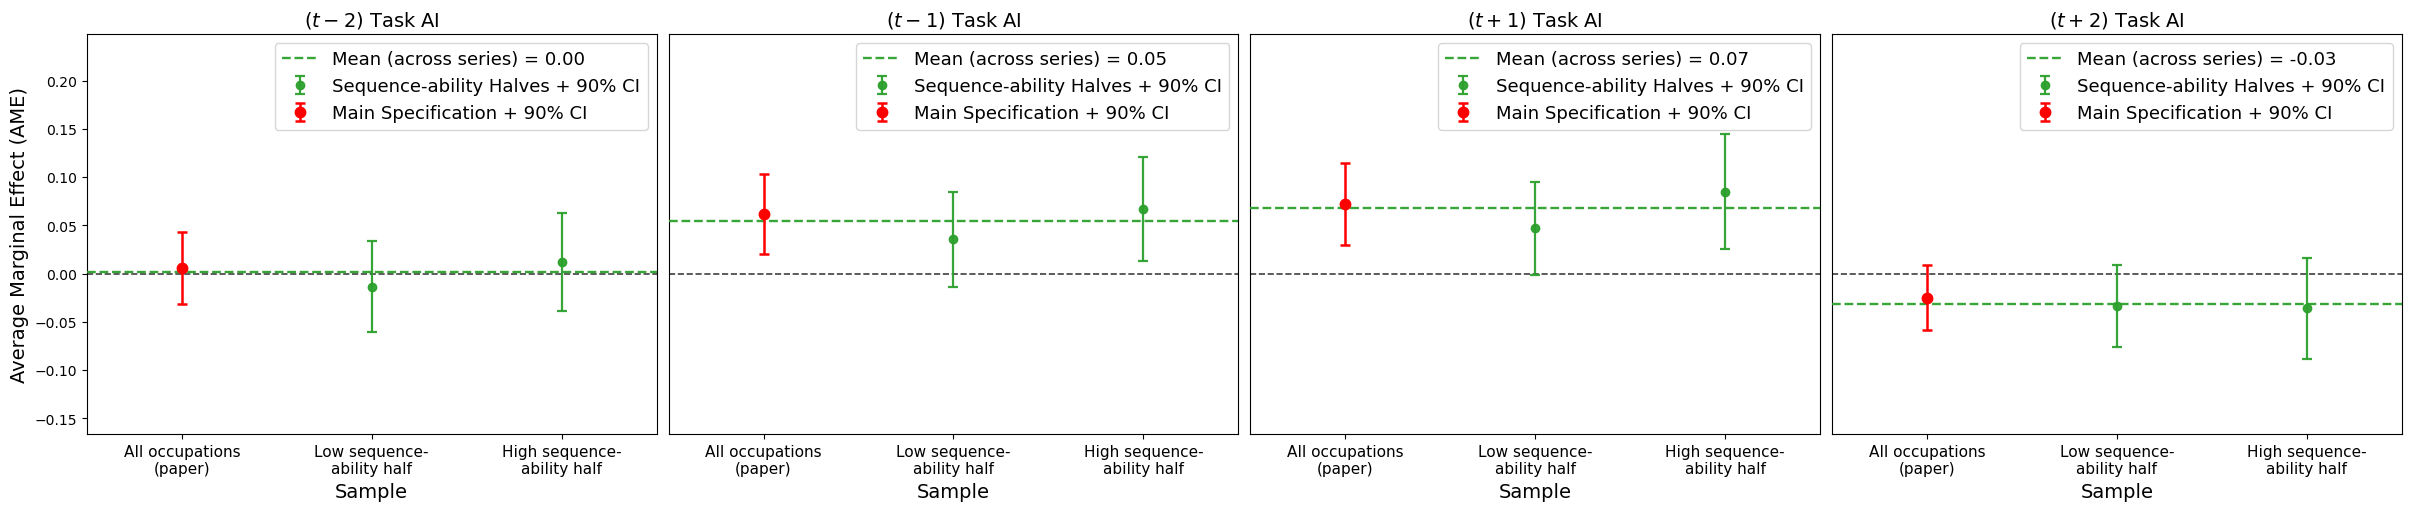

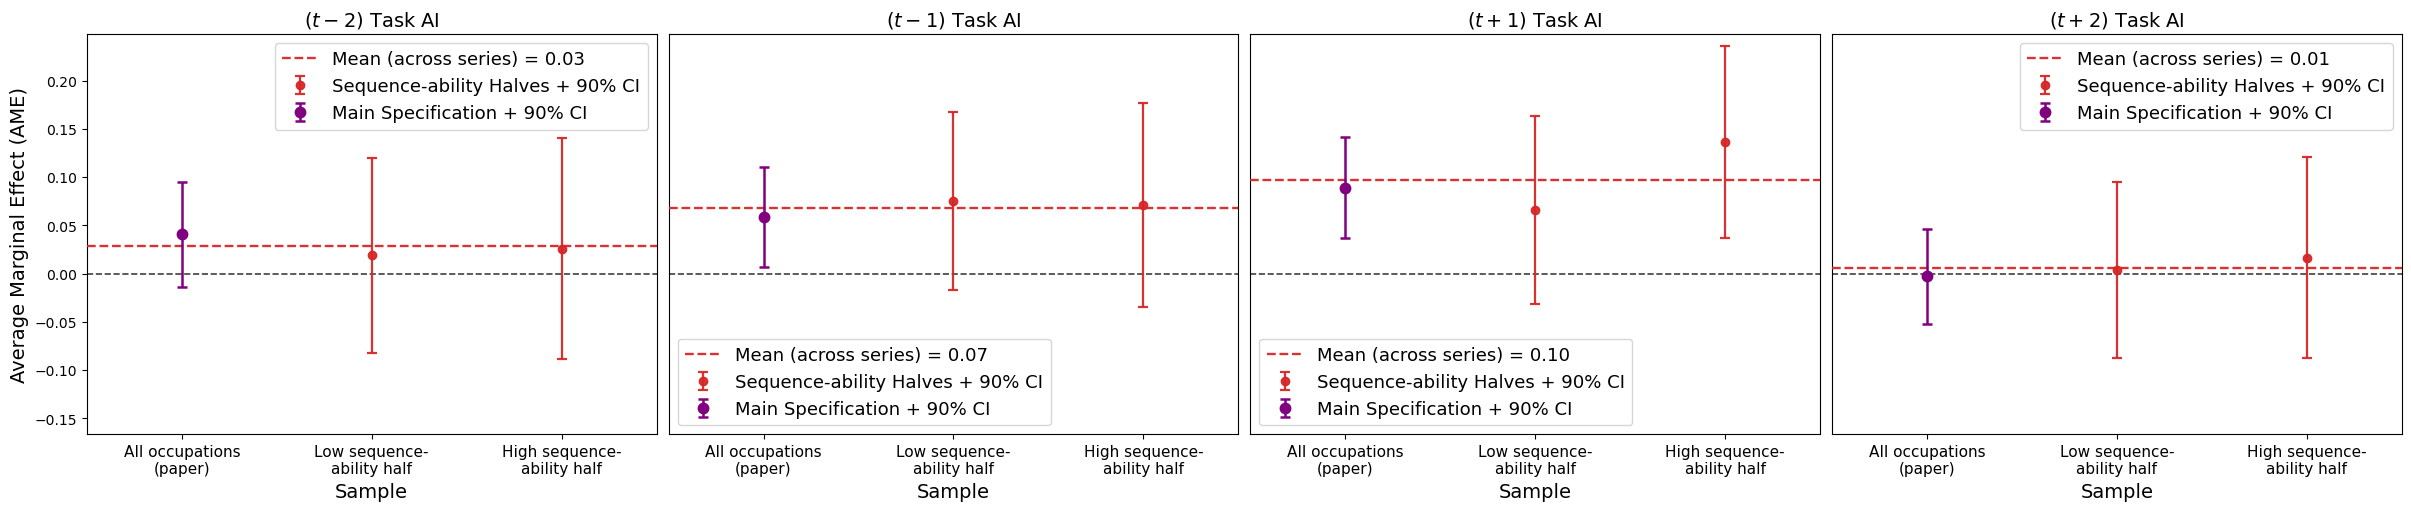

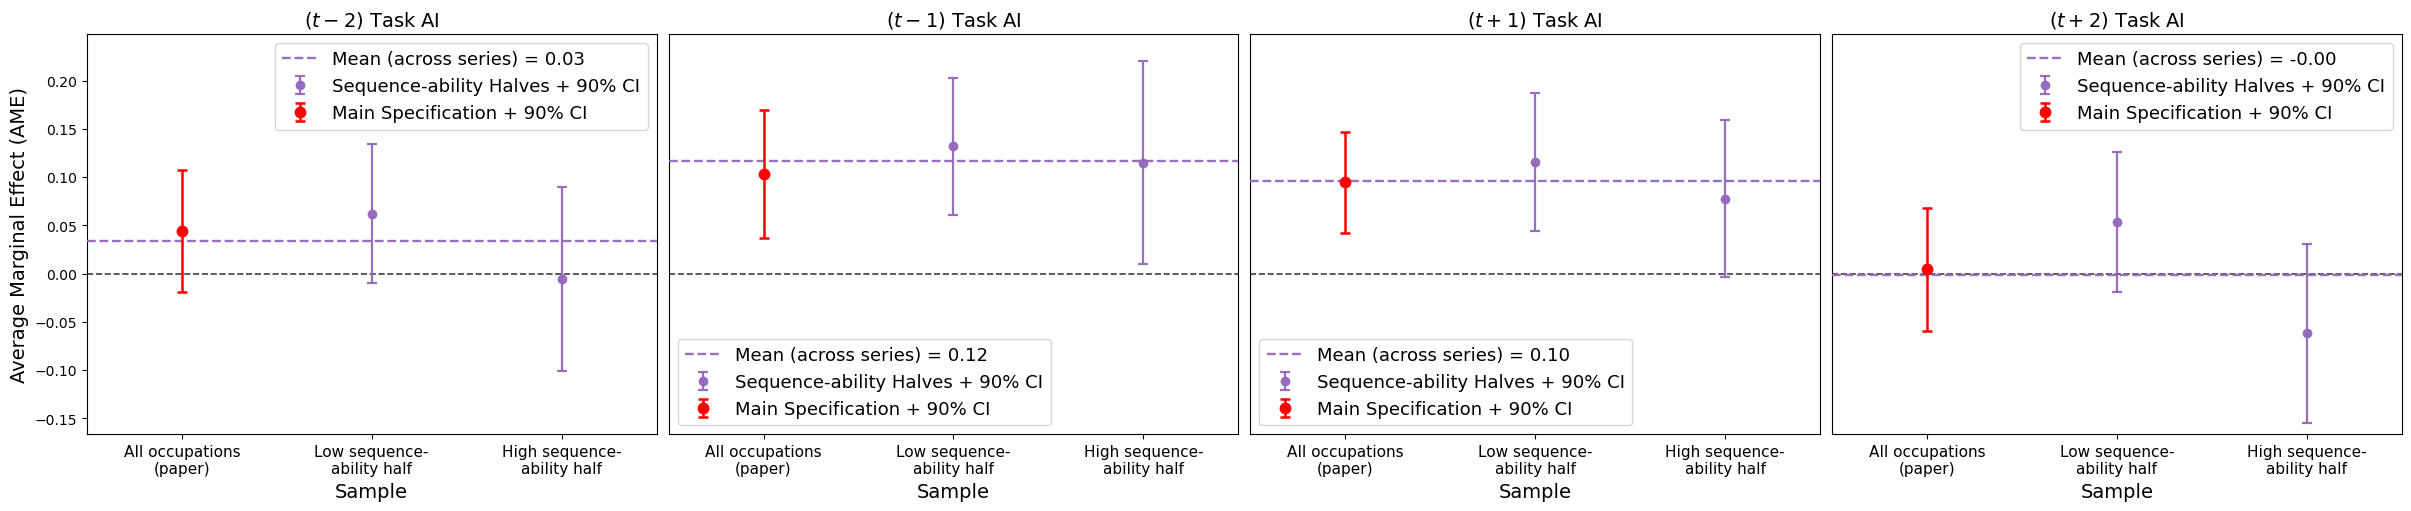

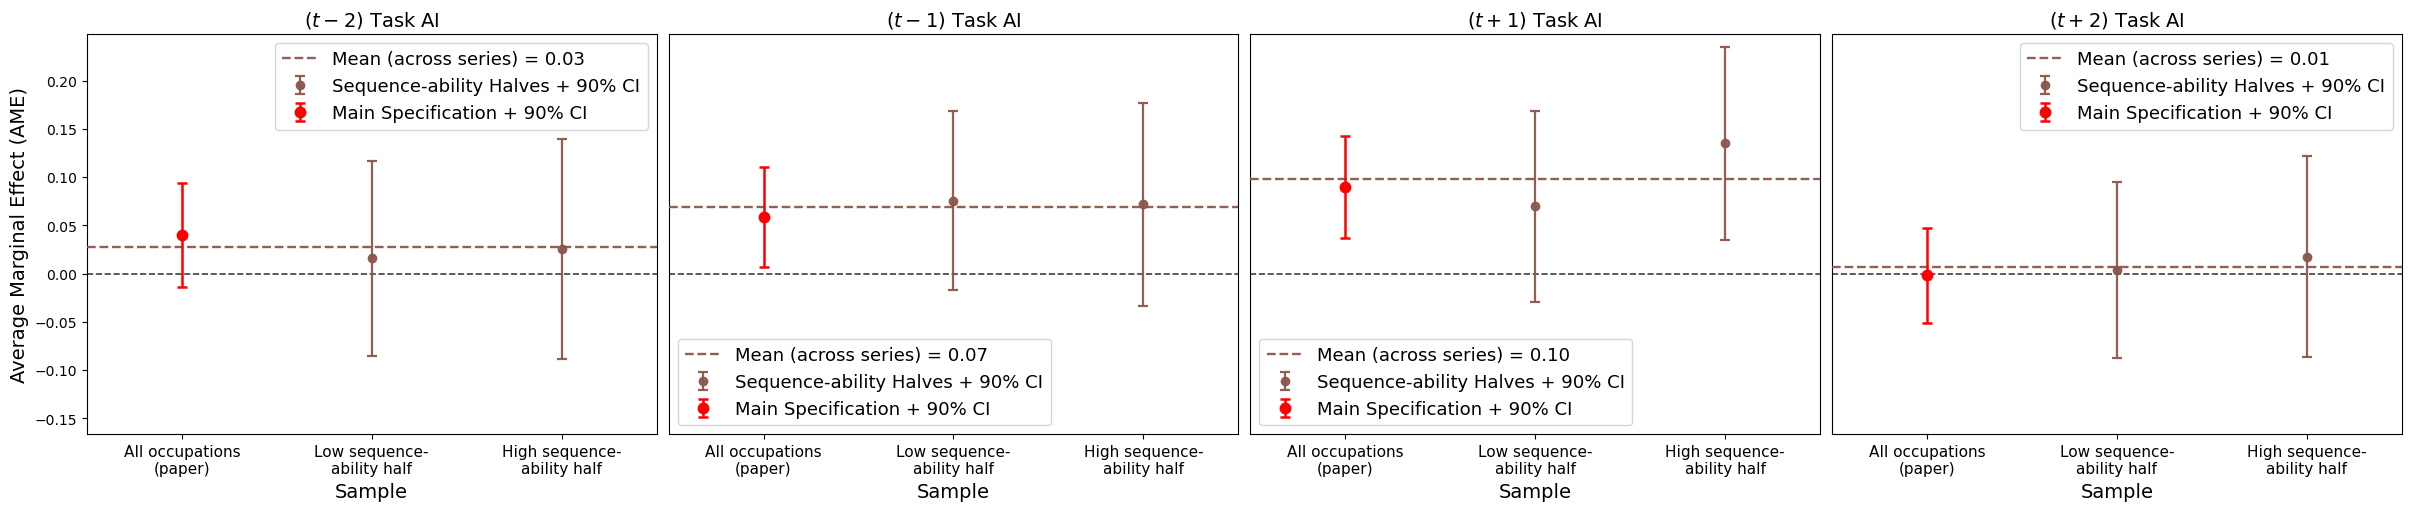

Saved 12 figures to ../writeup/plots/execTypeVaryingDWA_sequenceability


In [9]:
PLOT_TITLES = ['($t-2$) Task AI', '($t-1$) Task AI', '($t+1$) Task AI', '($t+2$) Task AI']
SPEC2COLOR = {spec: plt.cm.tab10(i % 10) for i, spec in enumerate(SPEC_ORDER)}
SERIES_X = {'all_occs': 0, 'low_seq': 1, 'high_seq': 2}
X_TICKLABELS = ['All occupations\n(paper)', 'Low sequence-\nability half', 'High sequence-\nability half']
Z90 = 1.645

for ds_name, suffix in [('full_eligible', ''), ('gpt_filtered', '_gptFiltered')]:
    dfp = plotdf[(plotdf.dataset == ds_name) & (plotdf.term.isin(TARGET_REGS))].copy()
    dfp['x'] = dfp['series'].map(SERIES_X)
    dfp['ci_low'] = dfp['ame_coef'] - Z90 * dfp['ame_se']
    dfp['ci_high'] = dfp['ame_coef'] + Z90 * dfp['ame_se']
    ylims = (min(-0.075, dfp['ci_low'].min() - 0.012), max(0.19, dfp['ci_high'].max() + 0.012))
    for si, spec in enumerate(SPEC_ORDER):
        spec_color = SPEC2COLOR[spec]
        main_color = 'purple' if si == 3 else 'red'
        fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)
        for j, (reg, title) in enumerate(zip(TARGET_REGS, PLOT_TITLES)):
            ax = axes[j]
            sub = dfp[(dfp['model'] == spec) & (dfp['term'] == reg)].sort_values('x')
            ax.axhline(0, color='0.25', lw=1.2, ls='--', zorder=0)
            x = sub['x'].astype(float).values; y = sub['ame_coef'].astype(float).values
            lo = sub['ci_low'].astype(float).values; hi = sub['ci_high'].astype(float).values
            yerr = np.vstack([y - lo, hi - y]); mask0 = (x == 0); m = ~mask0
            if m.any():
                ax.errorbar(x[m], y[m], yerr=yerr[:, m], fmt='o', ms=6, color=spec_color, ecolor=spec_color,
                            elinewidth=1.6, capsize=3.5, capthick=1.6, alpha=0.95, zorder=3,
                            label='Sequence-ability Halves + 90% CI')
            if mask0.any():
                ax.errorbar(x[mask0], y[mask0], yerr=yerr[:, mask0], fmt='o', ms=7.5, color=main_color,
                            ecolor=main_color, elinewidth=1.8, capsize=3.5, capthick=1.8, alpha=1.0, zorder=6,
                            label='Main Specification + 90% CI')
            y_mean = float(np.nanmean(y))
            ax.axhline(y_mean, color=spec_color, ls='--', lw=1.7, alpha=0.95, zorder=3,
                       label=f'Mean (across series) = {y_mean:.2f}')
            ax.set_title(title, fontsize=14)
            ax.set_xlim(-0.5, 2.5); ax.set_xticks([0, 1, 2]); ax.set_xticklabels(X_TICKLABELS, fontsize=11)
            ax.set_xlabel('Sample', fontsize=14)
            ax.set_ylim(*ylims)
            ax.legend(loc='best', fontsize=13)
            if j == 0:
                ax.set_ylabel('Average Marginal Effect (AME)', fontsize=14)
            else:
                ax.set_ylabel(''); ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        fig.savefig(f"{output_plot_path}/ame_{spec}_seqAbilitySplit{suffix}.png", dpi=200, bbox_inches='tight')
        plt.show()
print('Saved 12 figures to', output_plot_path)